# DX799 — Weeks 1–4 

In [1]:
# ==============================================
# 1) CONFIG
# ==============================================
EMISSIONS_PATH = 'emissions_medium_granularity.csv'
FUELS_PATH     = 'all_fuels_data.csv'
PIPELINE_PATH  = 'Oil_Pipeline.csv'
EM_COMPANY_COL    = 'parent_entity'
EM_YEAR_COL       = 'year'
EM_EMISSIONS_COL  = 'total_emissions_MtCO2e'
EM_PRODUCTION_COL = 'production_value'
FUEL_YEAR_COL  = 'date'   # will be converted to year
FUEL_PRICE_COL = 'close'
PIPE_DATE_OR_YEAR_COL = 'Accident Year'
OUTER_SPLITS = 5; INNER_SPLITS = 5; RANDOM_STATE = 42


In [2]:
# ==============================================
# 2) LOAD DATA + HELPERS + STYLE
# ==============================================
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV, cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix, RocCurveDisplay
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
os.makedirs('figures', exist_ok=True)
def set_viz_style():
    mpl.rcParams.update({'figure.dpi': 120,'savefig.dpi': 200,'figure.autolayout': True,'axes.grid': True,'grid.linestyle': '--','grid.alpha': 0.3,'axes.spines.top': False,'axes.spines.right': False,'lines.linewidth': 1.8,'font.size': 11,'axes.titlesize': 12,'axes.labelsize': 11,'xtick.labelsize': 10,'ytick.labelsize': 10,'legend.fontsize': 10})
set_viz_style()
def eval_regression(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred))); mae = float(mean_absolute_error(y_true, y_pred)); r2 = float(r2_score(y_true, y_pred)); return {'R2': r2, 'RMSE': rmse, 'MAE': mae}
em_df = pd.read_csv(EMISSIONS_PATH); fuels_df = pd.read_csv(FUELS_PATH); pipe_df = pd.read_csv(PIPELINE_PATH)
print('EMISSIONS columns:', list(em_df.columns)); print('FUELS columns:', list(fuels_df.columns)); print('PIPELINE columns:', list(pipe_df.columns))


EMISSIONS columns: ['year', 'parent_entity', 'parent_type', 'commodity', 'production_value', 'production_unit', 'total_emissions_MtCO2e']
FUELS columns: ['ticker', 'commodity', 'date', 'open', 'high', 'low', 'close', 'volume']
PIPELINE columns: ['Report Number', 'Supplemental Number', 'Accident Year', 'Accident Date/Time', 'Operator ID', 'Operator Name', 'Pipeline/Facility Name', 'Pipeline Location', 'Pipeline Type', 'Liquid Type', 'Liquid Subtype', 'Liquid Name', 'Accident City', 'Accident County', 'Accident State', 'Accident Latitude', 'Accident Longitude', 'Cause Category', 'Cause Subcategory', 'Unintentional Release (Barrels)', 'Intentional Release (Barrels)', 'Liquid Recovery (Barrels)', 'Net Loss (Barrels)', 'Liquid Ignition', 'Liquid Explosion', 'Pipeline Shutdown', 'Shutdown Date/Time', 'Restart Date/Time', 'Public Evacuations', 'Operator Employee Injuries', 'Operator Contractor Injuries', 'Emergency Responder Injuries', 'Other Injuries', 'Public Injuries', 'All Injuries', 'Ope

In [3]:
# ==============================================
# 3) MERGE (company–year)
# ==============================================
model_df = em_df[[EM_COMPANY_COL, EM_YEAR_COL, EM_EMISSIONS_COL]].copy(); model_df.columns = ['company','year','emissions']
if EM_PRODUCTION_COL in em_df.columns:
    tmp = em_df[[EM_COMPANY_COL, EM_YEAR_COL, EM_PRODUCTION_COL]].copy(); tmp.columns = ['company','year','production']; model_df = model_df.merge(tmp, on=['company','year'], how='left')
fu = fuels_df.copy(); fu[FUEL_YEAR_COL] = pd.to_datetime(fu[FUEL_YEAR_COL], errors='coerce').dt.year
price_df = fu.groupby(FUEL_YEAR_COL, as_index=False)[FUEL_PRICE_COL].mean().rename(columns={FUEL_YEAR_COL:'year', FUEL_PRICE_COL:'avg_price'})
model_df = model_df.merge(price_df, on='year', how='left')
inc = pipe_df.groupby(PIPE_DATE_OR_YEAR_COL).size().reset_index(name='incident_count'); inc.columns = ['year','incident_count']; inc['year'] = pd.to_numeric(inc['year'], errors='coerce')
model_df = model_df.merge(inc, on='year', how='left')
for c in ['emissions','production','avg_price','incident_count']:
    if c in model_df.columns: model_df[c] = pd.to_numeric(model_df[c], errors='coerce')
model_df = model_df.dropna(subset=['emissions']).reset_index(drop=True)
print('Modeling table shape:', model_df.shape); display(model_df.head(10)); model_df.head(50).to_csv('figures/model_df_preview.csv', index=False)


Modeling table shape: (30921, 6)


,company,year,emissions,production,avg_price,incident_count
0,Abu Dhabi National Oil Company,1962,0.363885,0.91250,NaN,NaN
1,Abu Dhabi National Oil Company,1962,0.363885,1.84325,NaN,NaN
2,Abu Dhabi National Oil Company,1962,0.134355,0.91250,NaN,NaN
3,Abu Dhabi National Oil Company,1962,0.134355,1.84325,NaN,NaN
4,Abu Dhabi National Oil Company,1963,0.727770,1.82500,NaN,NaN
5,Abu Dhabi National Oil Company,1963,0.727770,4.42380,NaN,NaN
6,Abu Dhabi National Oil Company,1963,0.322453,1.82500,NaN,NaN
7,Abu Dhabi National Oil Company,1963,0.322453,4.42380,NaN,NaN
8,Abu Dhabi National Oil Company,1964,2.911079,7.30000,NaN,NaN
9,Abu Dhabi National Oil Company,1964,2.911079,17.32655,NaN,NaN


emissions         0.000000
production        0.000000
avg_price         0.603829
incident_count    0.771320
Name: NaN_rate, dtype: float64

,emissions,production,avg_price,incident_count
year,,,,
1854,0.0,0.0,1.0,1.0
1855,0.0,0.0,1.0,1.0
1856,0.0,0.0,1.0,1.0
1857,0.0,0.0,1.0,1.0
1858,0.0,0.0,1.0,1.0


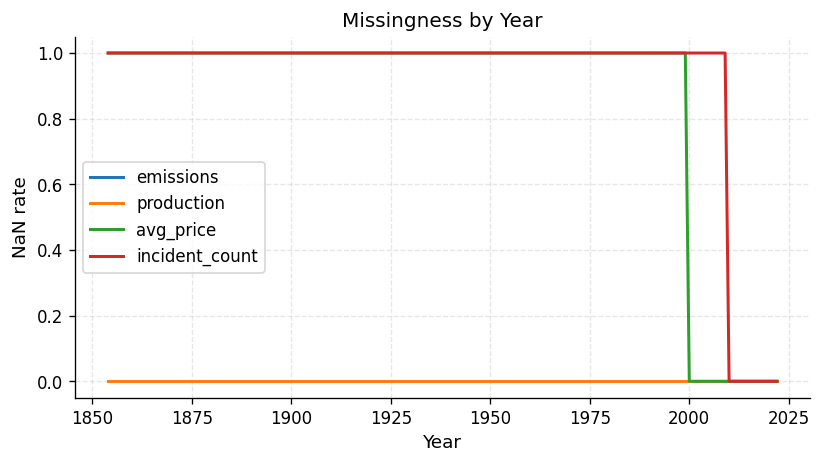

In [4]:
# 3A) EDA — Missingness (overall + by year)
key_cols = ['emissions','production','avg_price','incident_count']
miss_overall = model_df[key_cols].isna().mean().rename('NaN_rate'); display(miss_overall); miss_overall.to_csv('figures/eda_missing_overall.csv')
miss_year = model_df.groupby('year')[key_cols].apply(lambda df: df.isna().mean()); display(miss_year.head()); miss_year.to_csv('figures/eda_missing_by_year.csv')
set_viz_style(); plt.figure(figsize=(7,4))
for c in key_cols:
    if c in model_df.columns: plt.plot(miss_year.index, miss_year[c], label=c)
plt.xlabel('Year'); plt.ylabel('NaN rate'); plt.title('Missingness by Year'); plt.legend(); plt.tight_layout(); plt.savefig('figures/eda_missing_by_year.png', dpi=200, bbox_inches='tight'); plt.show()


In [5]:
# 3B) EDA — Units & Categories
if 'production_unit' in em_df.columns:
    unit_counts = em_df['production_unit'].value_counts(dropna=False); display(unit_counts.head(10)); unit_counts.to_csv('figures/eda_production_units_counts.csv')
if 'commodity' in em_df.columns:
    commodity_counts = em_df['commodity'].value_counts().head(15); display(commodity_counts); commodity_counts.to_csv('figures/eda_commodity_counts.csv')


production_unit
Million tonnes/yr     5103
Million bbl/yr        3733
Bcf/yr                3452
Million Tonnes CO2     263
Name: count, dtype: int64

commodity
Oil & NGL              3733
Natural Gas            3452
Bituminous Coal        1370
Metallurgical Coal     1073
Lignite Coal           1008
Sub-Bituminous Coal     673
Thermal Coal            611
Anthracite Coal         368
Cement                  263
Name: count, dtype: int64

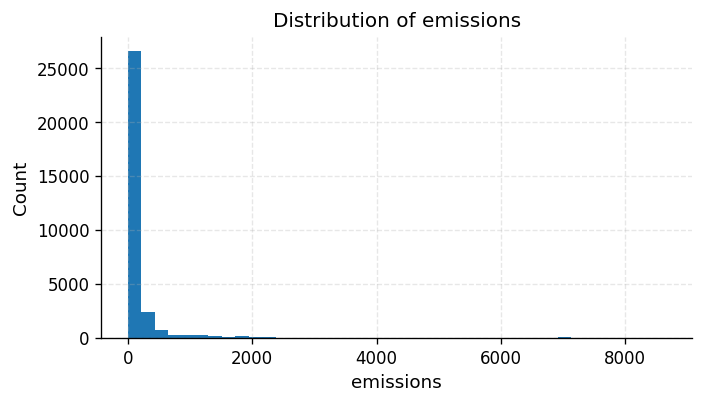

emissions: outlier rate ~ 0.113 (lo=-149.70, hi=273.49)


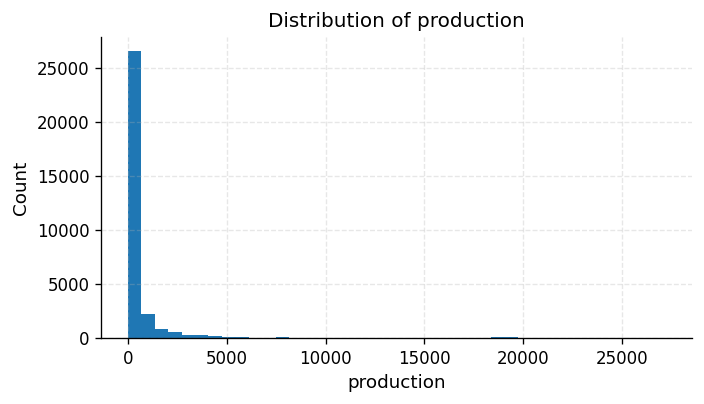

production: outlier rate ~ 0.141 (lo=-398.21, hi=687.44)


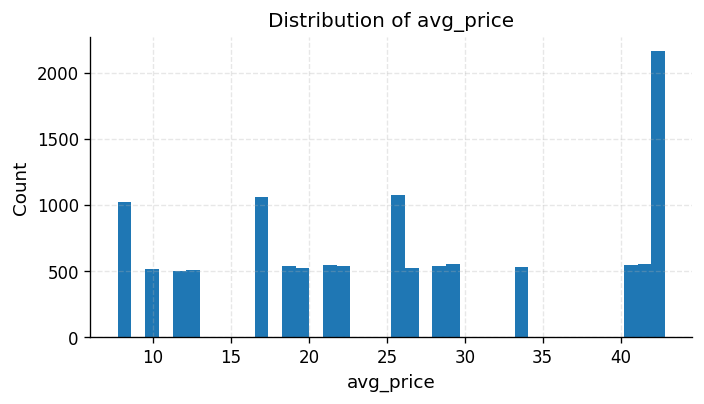

avg_price: outlier rate ~ 0.000 (lo=-17.30, hi=74.83)


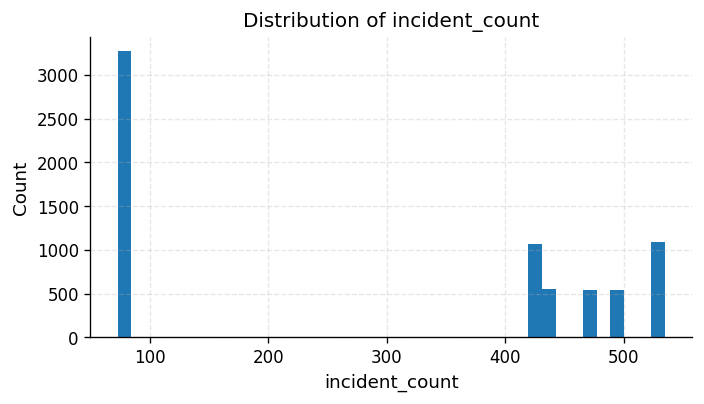

incident_count: outlier rate ~ 0.000 (lo=-510.00, hi=1066.00)


In [6]:
# 3C) EDA — Distributions & IQR Outliers
import numpy as np
numeric = [c for c in ['emissions','production','avg_price','incident_count'] if c in model_df.columns]
for c in numeric:
    s = model_df[c].dropna(); set_viz_style(); plt.figure(figsize=(6,3.5)); plt.hist(s, bins=40); plt.title(f'Distribution of {c}'); plt.xlabel(c); plt.ylabel('Count'); plt.tight_layout(); plt.savefig(f'figures/eda_dist_{c}.png', dpi=200, bbox_inches='tight'); plt.show()
    q1, q3 = np.percentile(s, [25, 75]); iqr = q3-q1; lo, hi = q1-1.5*iqr, q3+1.5*iqr; out_rate = float(((s<lo)|(s>hi)).mean()); print(f'{c}: outlier rate ~ {out_rate:.3f} (lo={lo:.2f}, hi={hi:.2f})')


,emissions,production,avg_price,incident_count
year,,,,
1854,0.033066,0.017002,NaN,NaN
1855,0.042999,0.022109,NaN,NaN
1856,0.052931,0.027216,NaN,NaN
1857,0.061527,0.031635,NaN,NaN
1858,0.070122,0.036055,NaN,NaN


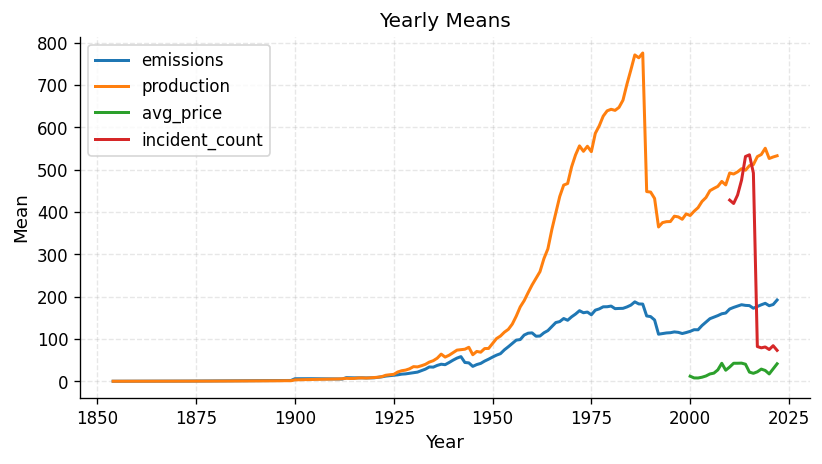

In [7]:
# 3D) EDA — Yearly Means
agg = model_df.groupby('year')[numeric].mean(); display(agg.head()); set_viz_style(); plt.figure(figsize=(7,4))
for c in numeric: plt.plot(agg.index, agg[c], label=c)
plt.xlabel('Year'); plt.ylabel('Mean'); plt.title('Yearly Means'); plt.legend(); plt.tight_layout(); plt.savefig('figures/eda_yearly_means.png', dpi=200, bbox_inches='tight'); plt.show()


In [8]:
# 3E) EDA — VIF
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
def compute_vif(df):
    X = SimpleImputer(strategy='median').fit_transform(df); X = StandardScaler().fit_transform(X)
    cols = df.columns; import numpy as np, pandas as pd
    vifs = []
    for i in range(X.shape[1]):
        y = X[:, i]; Xo = np.delete(X, i, axis=1)
        if Xo.shape[1] == 0: vifs.append(np.nan); continue
        r2 = LinearRegression().fit(Xo, y).score(Xo, y)
        vifs.append(float(np.inf if (1-r2)<=1e-12 else 1.0/(1.0-r2)))
    return pd.Series(vifs, index=cols, name='VIF')
feat_cols = [c for c in ['production','avg_price','incident_count'] if c in model_df.columns]
if feat_cols:
    vif_series = compute_vif(model_df[feat_cols]); display(vif_series); vif_series.to_csv('figures/eda_vif.csv')


production        1.000467
avg_price         1.001754
incident_count    1.002000
Name: VIF, dtype: float64

                  count unique                  top  freq         mean  \
company           30921    122  Former Soviet Union  2372          NaN   
year            30921.0    NaN                  NaN   NaN  1986.363248   
emissions       30921.0    NaN                  NaN   NaN   137.877579   
production      30921.0    NaN                  NaN   NaN   430.869227   
avg_price       12250.0    NaN                  NaN   NaN    25.814819   
incident_count   7071.0    NaN                  NaN   NaN   291.536558   

                        std       min        25%        50%         75%  \
company                 NaN       NaN        NaN        NaN         NaN   
year              29.105604    1854.0     1972.0     1993.0      2008.0   
emissions        406.850994  0.000321   8.997736  35.368808  114.795758   
production      1544.525152  0.004398   8.907516      55.48      280.32   
avg_price         11.781564  7.736297  17.244079  25.490292   40.276604   
incident_count   199.941468    

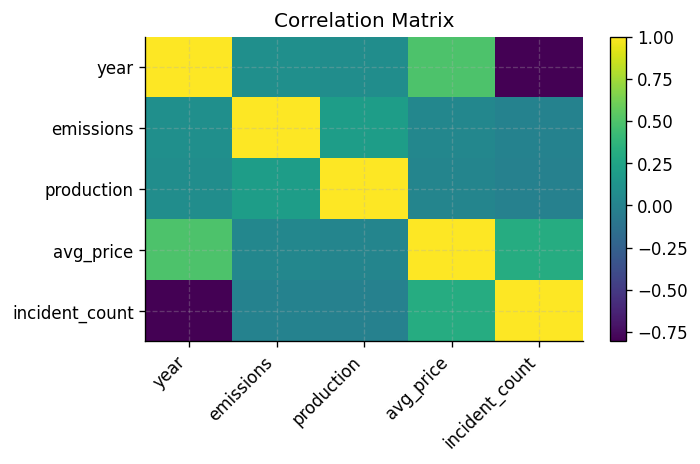

In [9]:
# 4) EDA (lite)
print(model_df.describe(include='all').T)
num_cols = model_df.select_dtypes(include='number').columns.tolist(); corr = model_df[num_cols].corr()
set_viz_style(); plt.figure(figsize=(6,4)); plt.imshow(corr, aspect='auto'); plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right'); plt.yticks(range(len(num_cols)), num_cols); plt.title('Correlation Matrix'); plt.colorbar(); plt.tight_layout(); plt.savefig('figures/week0_correlation_matrix.png', dpi=200, bbox_inches='tight'); plt.show(); model_df.describe(include='all').T.to_csv('figures/eda_describe.csv')


,R2,RMSE,MAE
OLS,0.040116,398.600324,150.880558
OLS+Poly,0.058496,394.765680,146.871751


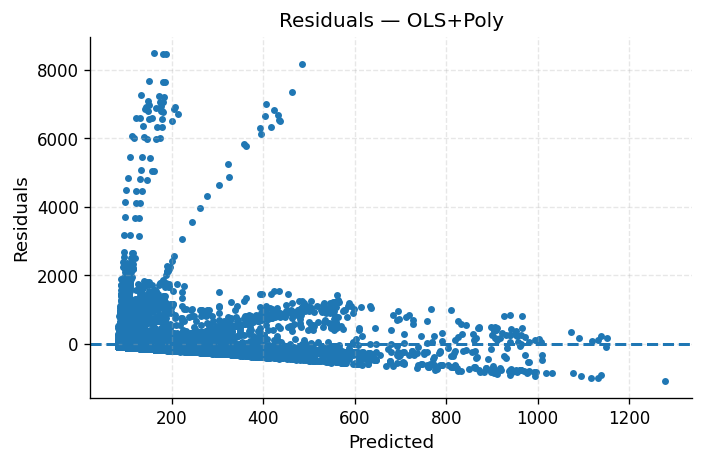

In [10]:
# 5) Week 1 — OLS vs OLS+Polynomial
FEATURES = [c for c in ['production','avg_price','incident_count'] if c in model_df.columns]; X = model_df[FEATURES].copy(); y = model_df['emissions'].copy()
cv_pred = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipe_base = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ols', LinearRegression())])
yhat_base = cross_val_predict(pipe_base, X, y, cv=cv_pred, n_jobs=1); m_base = eval_regression(y, yhat_base)
pipe_poly = Pipeline([('imputer', SimpleImputer(strategy='median')), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('scaler', StandardScaler()), ('ols', LinearRegression())])
yhat_poly = cross_val_predict(pipe_poly, X, y, cv=cv_pred, n_jobs=1); m_poly = eval_regression(y, yhat_poly)
tbl = pd.DataFrame([m_base, m_poly], index=['OLS','OLS+Poly']); display(tbl); tbl.to_csv('figures/week1_metrics_table.csv')
best = 'OLS+Poly' if tbl.loc['OLS+Poly','RMSE'] < tbl.loc['OLS','RMSE'] else 'OLS'; best_pred = yhat_poly if best=='OLS+Poly' else yhat_base
set_viz_style(); plt.figure(figsize=(6,4)); plt.scatter(best_pred, y - best_pred, s=10); plt.axhline(0, linestyle='--'); plt.xlabel('Predicted'); plt.ylabel('Residuals'); plt.title('Residuals — ' + best); plt.tight_layout(); plt.savefig('figures/week1_residuals.png', dpi=200, bbox_inches='tight'); plt.show()


In [11]:
# 5B) Week 1 — Repeated-CV summary (optional log1p)
FEATS = FEATURES.copy(); X2 = model_df[FEATS].copy(); y2 = model_df['emissions'].copy(); use_log1p = (y2.min()>0) and all((X2[c].min()>0) for c in FEATS)
if use_log1p:
    X2 = np.log1p(X2); y2 = np.log1p(y2); print('Applied log1p to X and y')
cv_rep  = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
pipe_std = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ols', LinearRegression())])
r2 = cross_val_score(pipe_std, X2, y2, cv=cv_rep, scoring='r2', n_jobs=1); rmse = -cross_val_score(pipe_std, X2, y2, cv=cv_rep, scoring='neg_root_mean_squared_error', n_jobs=1); mae = -cross_val_score(pipe_std, X2, y2, cv=cv_rep, scoring='neg_mean_absolute_error', n_jobs=1)
pd.DataFrame({'R2': r2, 'RMSE': rmse, 'MAE': mae}).describe().to_csv('figures/week1_repeatedcv_summary.csv'); print('Saved: figures/week1_repeatedcv_summary.csv')


Applied log1p to X and y
Saved: figures/week1_repeatedcv_summary.csv


Saved: figures/week2_nested_cv_summary.json


,coef
incident_count,-10.153501
avg_price,8.973532
production,79.676413


Elastic Net (KFold-pred) metrics: {'R2': 0.04011783242625533, 'RMSE': 398.6000243570569, 'MAE': 150.95953513283476}


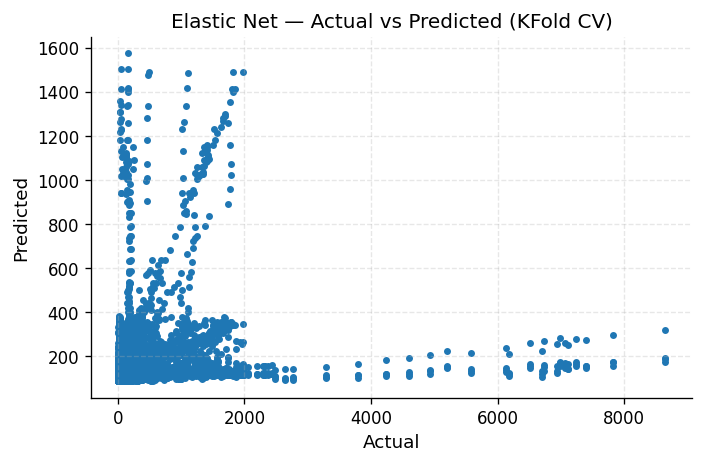

In [13]:
# 6) Week 2 — Elastic Net (Nested CV + KFold diagnostics) 
X = model_df[[c for c in ['production','avg_price','incident_count'] if c in model_df.columns]].copy()
y = model_df['emissions'].copy()
pipe_en = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('en', ElasticNet(max_iter=20000, random_state=RANDOM_STATE))
])
param_grid = {
    'en__alpha': np.logspace(-3, 1, 8),
    'en__l1_ratio': [0.2, 0.5, 0.8, 1.0]
}
outer_cv = KFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
outer_scores = []
best_params = []
for tr, te in outer_cv.split(X, y):
    gs = GridSearchCV(pipe_en, param_grid, cv=inner_cv, scoring='r2', n_jobs=1)
    gs.fit(X.iloc[tr], y.iloc[tr])
    y_hat = gs.best_estimator_.predict(X.iloc[te])
    outer_scores.append(r2_score(y.iloc[te], y_hat))
    best_params.append(gs.best_params_)
nested = {
    'outer_mean_R2': float(np.mean(outer_scores)),
    'outer_std_R2': float(np.std(outer_scores)),
    'samples': best_params[:5]
}
with open('figures/week2_nested_cv_summary.json','w') as f:
    json.dump(nested, f, indent=2)
print('Saved: figures/week2_nested_cv_summary.json')
gs_final = GridSearchCV(pipe_en, param_grid, cv=inner_cv, scoring='r2', n_jobs=1)
gs_final.fit(X, y)
best_en = gs_final.best_estimator_
coef_tbl = pd.Series(best_en.named_steps['en'].coef_, index=X.columns).to_frame('coef').sort_values('coef')
display(coef_tbl)
coef_tbl.to_csv('figures/week2_elasticnet_coefs.csv')
cv_pred = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_hat = cross_val_predict(best_en, X, y, cv=cv_pred, n_jobs=1)
metrics = eval_regression(y, y_hat)
print('Elastic Net (KFold-pred) metrics:', metrics)
pd.DataFrame([metrics]).to_csv('figures/week2_elasticnet_kfoldpred_metrics.csv', index=False)
set_viz_style(); plt.figure(figsize=(6,4))
plt.scatter(y, y_hat, s=10)
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Elastic Net — Actual vs Predicted (KFold CV)')
plt.tight_layout(); plt.savefig('figures/week2_actual_vs_pred_kfold.png', dpi=200, bbox_inches='tight'); plt.show()


In [15]:
# 6B) Week 2 — Compare Ridge, Lasso, Elastic Net (Nested CV)
X = model_df[[c for c in ['production','avg_price','incident_count'] if c in model_df.columns]].copy(); y = model_df['emissions'].copy()
pipes = {
  'Ridge': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('est', Ridge(random_state=RANDOM_STATE))]),
  'Lasso': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('est', Lasso(random_state=RANDOM_STATE, max_iter=20000))]),
  'ElasticNet': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('est', ElasticNet(random_state=RANDOM_STATE, max_iter=20000))])
}
grids = {
  'Ridge': {'est__alpha': np.logspace(-4,2,12)},
  'Lasso': {'est__alpha': np.logspace(-4,2,12)},
  'ElasticNet': {'est__alpha': np.logspace(-4,2,12), 'est__l1_ratio': [0.2, .2, .5, .8, 1.0]},
}
outer = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE); inner = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name in pipes:
    scores = []; bests = []
    for tr, te in outer.split(X, y):
        gs = GridSearchCV(pipes[name], grids[name], cv=inner, scoring='r2', n_jobs=1); gs.fit(X.iloc[tr], y.iloc[tr]); scores.append(gs.best_estimator_.score(X.iloc[te], y.iloc[te])); bests.append(gs.best_params_)
    rows.append({'model': name, 'outer_mean_R2': float(np.mean(scores)), 'outer_std_R2': float(np.std(scores)), 'best_samples': bests})
res_df = pd.DataFrame(rows); display(res_df); res_df.to_csv('figures/week2_nestedcv_ridge_lasso_en.csv', index=False)


,model,outer_mean_R2,outer_std_R2,best_samples
0,Ridge,0.040140,0.007936,"[{'est__alpha': 100.0}, {'est__alpha': 100.0},..."
1,Lasso,0.040038,0.007960,"[{'est__alpha': 0.6579332246575675}, {'est__al..."
2,ElasticNet,0.040046,0.007871,"[{'est__alpha': 0.05336699231206307, 'est__l1_..."


In [16]:
# 8) Week 3 — Stepwise LR, PCR, PLSR
from sklearn.model_selection import KFold, cross_val_score
def cv_r2(feats):
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ols', LinearRegression())])
    return float(np.mean(cross_val_score(pipe, X[feats], y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2', n_jobs=1)))
cands = FEATURES.copy(); best=-np.inf; forward=[]; remaining=cands.copy()
while remaining:
    trial=[(f, cv_r2(forward+[f])) for f in remaining]
    f_best, s_best = max(trial, key=lambda t:t[1])
    if s_best>best+1e-6: forward.append(f_best); remaining.remove(f_best); best=s_best
    else: break
back=cands.copy(); improved=True
while improved and len(back)>1:
    base=cv_r2(back); drops=[(f, cv_r2([x for x in back if x!=f])) for f in back]
    f_drop, s_drop = max(drops, key=lambda t:t[1])
    if s_drop>base+1e-6: back.remove(f_drop)
    else: improved=False
print({'forward_feats': forward, 'forward_cv_r2': cv_r2(forward), 'backward_feats': back, 'backward_cv_r2': cv_r2(back)})
pipe_pcr = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('pca', PCA()), ('ols', LinearRegression())])
gs_pcr = GridSearchCV(pipe_pcr, {'pca__n_components': list(range(1, len(FEATURES)+1))}, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2', n_jobs=1)
gs_pcr.fit(X, y); print('PCR best:', gs_pcr.best_params_, 'R2:', float(gs_pcr.best_score_))
pipe_pls = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('pls', PLSRegression())])
gs_pls = GridSearchCV(pipe_pls, {'pls__n_components': list(range(1, len(FEATURES)+1))}, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2', n_jobs=1)
gs_pls.fit(X, y); print('PLSR best:', gs_pls.best_params_, 'R2:', float(gs_pls.best_score_))


{'forward_feats': ['production', 'incident_count', 'avg_price'], 'forward_cv_r2': 0.04013507256990019, 'backward_feats': ['production', 'avg_price', 'incident_count'], 'backward_cv_r2': 0.04013507256990016}
PCR best: {'pca__n_components': 3} R2: 0.04013507256990012
PLSR best: {'pls__n_components': 2} R2: 0.040137131670587814


In [17]:
# 9) Week 4 — Logistic Regression + Scaling
y_bin = (y >= float(np.nanpercentile(y, 75))).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_log = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))])
proba = cross_val_predict(pipe_log, X, y_bin, cv=cv, method='predict_proba', n_jobs=1)[:,1]
pred = (proba>=0.5).astype(int)
print({'AUC': float(roc_auc_score(y_bin, proba)), 'Accuracy': float(accuracy_score(y_bin, pred)), 'Precision': float(precision_score(y_bin, pred, zero_division=0)), 'Recall': float(recall_score(y_bin, pred, zero_division=0))})


{'AUC': 0.7649058223337561, 'Accuracy': 0.7800523915785389, 'Precision': 0.5724750623441397, 'Recall': 0.47510024576380805}
